# **TS2** Modelizando un ADC.
García Corona, Iara Paula <br>

Este trabajo propone realizar la simulación de un ADC, dispositivo electrónico que convierte una señal analógica continua en una digital discreta, tomando como señal de prueba una senoidal con ruido agregado.<br>Para esto se generan dos tipo de ruidos:
* Analógico aditivo: con una potencia definida a partir de la potencia de cuantización.
* De Cuantización; proveniente de la definición en bits que pueda otorgar el conversor.<br>
Se tiene como parámetros globales $f_s=1000Hz$ y $V_{FS}=\pm2V$, con una senoidal de frecuencia, $N=1000\ \ muestras$ y $\mu=0$.<br>
En el item a se pide el caso específico de un ADC con $B=4 bits$ y $k_n=1$, con tres gráficas que expongan su funcionamiento: en el dominio temporal, fercuencial en dB y un histograma del ruido de cuantización. El item b pide analizar qué sucede para una de estas configuraciones  $B=\{4,8,16\}$ y $k_n=\{frac{1}{10},1,10\}$ y compararlo con lo obtenido en el punto anterior.

Primero se definen las funciones básicas para el funcionamiento del programa

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def mi_funcion_sen(vmax, dc, ff, ph, nn, fs):
    xx=dc+vmax*np.sin(2*np.pi*ff*nn/fs+2*np.pi*ph)
    tt=nn/fs
    return(tt,xx)

def espectro_db(xx):
    N=len(xx)
    tr=(1/N)*np.fft.fft(xx)
    modulo_tr_db = 10 * np.log10(2*(np.abs(tr)[:N//2]) ** 2)
    return modulo_tr_db

def ADC (B, Vfs):
    qq=(2*Vfs)/(2**B) # paso de cuantizacion
    pq=qq**2/12 # Potencia teórica del ruido de cuantización
    return (qq,pq)

La función que se muestra a continuación es la encargada de procesar la información de las señales previo a los gráficos. Para poder realizar luego las modificaciones para los distintos valores de $B$ y $K_n$ se trasladó el proceso a una función para hacer más práctico el codeo. <br>
En esta instancia se implementa el modelo completo del ADC dada la configuración de bits y el coeficiente de ruido. Primero se calcula el paso de cuantización y la potenica de su ruido teórico en la llamada a la función <span style="color: blue;">ADC</span>. Luego se define el valor para la potencia del ruido analógico usando $P_n=k_n \cdot p_q$ para calcular su desvío estandar, valor necesario para la generación de la secuencia gaussiana incorrelada (<span style="color: hotpink;">yy</span>) que se suma a la señal limpia (<span style="color: hotpink;">xx</span>), dando como resultado la señal de entrada al conversor (<span style="color: hotpink;">funcion_con_ruido</span>).<br> Con estos valores establecidos, se realiza la cuantización redondeando la señal a múltiplo de qq, obteniendo finalmente la señal de salida del conversor (<span style="color: hotpink;">xx_q</span>) y el ruido de cuantización (<span style="color: hotpink;">nq</span>) como la diferencia entre ambas señales. Por último, se calculan los espectros en dB (<span style="color: hotpink;">abs_digital_db; abs_pura_db; abs_analogica_db</span>), los pisos de ruido (<span style="color: hotpink;">mu_digital_db; mu_analogica_db</span>) y se devuelven todas las variables para posteriormente poder analizarlas y graficarlas.

In [2]:
def cambiar_configuracion(B, kn):
    
    Vfs=2.0 #Volts
    qq,pq=ADC(B,Vfs)
    
    # Ruido analógico
    Pn=kn*pq # potencia del ruido analogico
    sig_ruido=np.sqrt(Pn) #Desviación estándar que necesita la función para generar el ruido
    
    #Señal con Ruido
    mu=0 #valor
    yy=np.random.normal(mu,sig_ruido,N)# ruido analógico
    funcion_con_ruido=xx+yy
    
    #Proceso de Cuantizacion
    
    "Cuantizacion"
    xx_q=np.round(funcion_con_ruido/qq)*qq
    nq=xx_q-funcion_con_ruido # ruido por cuantización    
    
    abs_digital_db=espectro_db(xx_q) #Señal con ruido de salida (ruido analógico + ruido de cuantización)
    mu_digital_db=np.mean(abs_digital_db)
    abs_pura_db=espectro_db(xx)
    abs_analogica_db=espectro_db(funcion_con_ruido)
    mu_analogica_db=np.mean(abs_analogica_db)
    return(xx_q,funcion_con_ruido,abs_digital_db,abs_pura_db,abs_analogica_db,nq,qq,mu_digital_db,mu_analogica_db)

Nuevamente, para hacer el codeo más práctico se generó una función que realiza los gráficos requeridos para el análisis de cada señal. Para evitar pasarle todas las variables necesarias, se llama directamente a <span style="color: blue;">cambiar_configuracion</span> dentro de esta función.

In [1]:
def graficador(B,kn,tt):
    xx_q,funcion_con_ruido,abs_digital_db,abs_pura_db,abs_analogica_db,nq,qq,mu_digital_db,mu_analogica_db=cambiar_configuracion(B,kn)
    fig=plt.figure(figsize=(10, 5))
    # Señales en el dominio Temporal
    plt.plot(tt, xx_q, label='Señal de Salida', color='blue',linestyle='-',linewidth=1.5, alpha=0.8) #señal con ruido
    plt.plot(tt, funcion_con_ruido, color='darkgreen', linestyle=':', marker='o', markersize=1, label='Señal de Entrada')
    plt.plot(tt, xx, ':', label='Señal limpia', color='orange', alpha=0.8) #ruido de la analogica
    # Formato de la gráfica
    plt.title(f"Señal muestreada por un ADC de {B} bits")
    plt.xlabel("Tiempo [S]")
    plt.ylabel("Amplitud [V]")
    plt.legend(loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.6)    
    plt.show()
    plt.close(fig)
    # Espectros
    fig=plt.figure(figsize=(10, 4))
    #xx_q
    plt.plot(frec, abs_digital_db, label='Señal de Salida', color='blue', linewidth=1, alpha=0.8) # Señal Cuantizada
    #xx
    plt.plot(frec, abs_pura_db, ':', label='Señal Limpia', color='orange', alpha=0.8) #Señal sin ruido
    #funcion_con_ruido
    plt.plot(frec, abs_analogica_db, ':', label='Señal de Salida', color='darkgreen', alpha=0.6) #señal con ruido
    #mu_digital_db
    plt.axhline(mu_digital_db,linestyle='--',label=f'Piso Digital={mu_digital_db: .2f}dB', color='navy',linewidth=1)
    #mu_analogica_db
    plt.axhline(mu_analogica_db,linestyle='--',label=f'Piso Analógico={mu_analogica_db: .2f}dB', color='green',linewidth=1)
    
    # Formato de la gráfica
    plt.title(f"Señal muestreada por un ADC de {B} bits y kn {kn}")
    plt.xlabel("Frecuencia [Hz]")
    plt.ylabel("Densidad de Potencia [dB]")
    plt.ylim(-80, 10)
    plt.legend(loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()
    plt.close(fig)
    return(qq,nq)



Además se generó una función que plotee el histograma del ruido de cuantizacipon comparado con la distribución teórica que este debería tener según la teoría de cuantización. 

In [10]:
def graficador_histograma(nq, qq, B):
    plt.figure(figsize=(8, 5))
    n_bins = 10
    counts, bins, _ = plt.hist(nq, bins=n_bins)
    esperado = len(nq) / n_bins  # altura teórica uniforme
    plt.axvline(-qq/2, color='red', linestyle='--')
    plt.axvline(qq/2, color='red', linestyle='--')
    plt.axhline(esperado, color='red', linestyle='--')
    plt.title(f"Ruido de cuantización para {B} bits - q = {qq:.2f} V")
    plt.xlabel("Ruido [V]")
    plt.ylabel("Frecuencia")
    #plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()

Se definen los parámetros generales. 

In [11]:
fs = 1000 # Hz
N = 1000 # muestras
nn=np.arange(0,N)

#Señal de entrada
pot_seno=1
vmax=np.sqrt(pot_seno*2) # (potencial máximo aka apmlitud máxima)
dc=0 # Valor medio (alrededor del que oscila)
df=fs/N # resolucion espectral
k=1 #bin
f_sen=k*df #frecuencia => fk=k*fs/N
ph=0

#Señal pura analógica
tt, xx= mi_funcion_sen(vmax, dc, f_sen, ph, nn, fs)
frec = np.fft.fftfreq(N, 1/fs)[:N//2] #Esto permite graficar en función de la frecuencia y no por los indices k 

Se generan los gráficos con $B=4$ y $k_n=1$

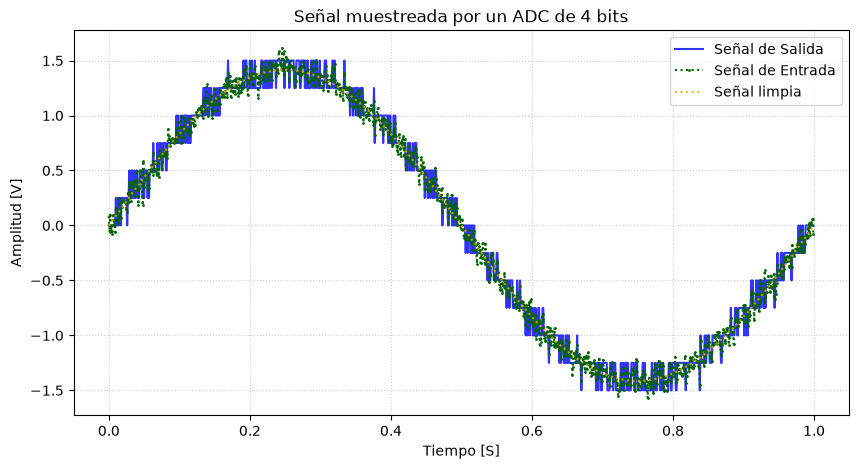

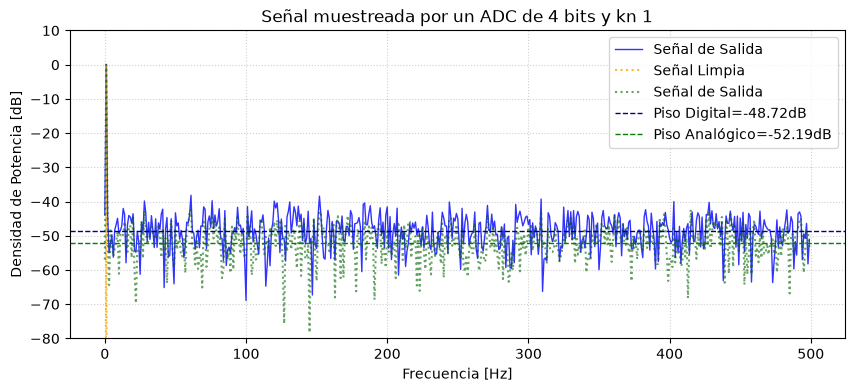

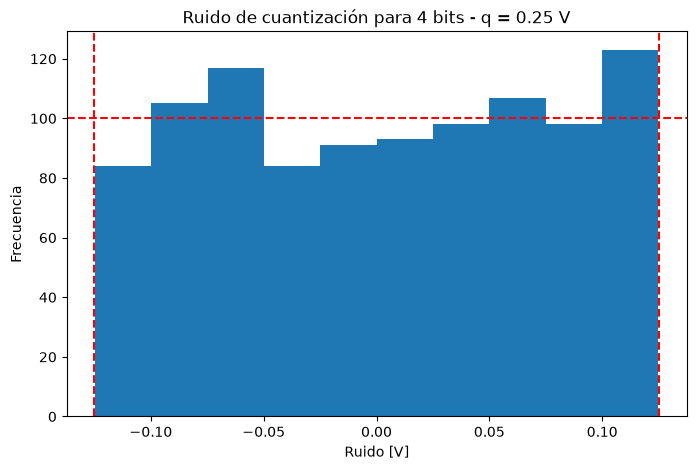

In [12]:
qq, nq=graficador(B=4,kn=1,tt=tt)
graficador_histograma(nq, qq, 4)

##### Gráficos en el dominio temporal:
En la primera figura se puede observar en naranja el esqueleto de la señal de entrada, una senoidal sin desfasaje con amplitud máxima $\sqrt 2 V$ (señal limpia), alrededor se ve el ruido analógico ya sumado (señak de entrada) y la señal cuantizada (señal de salida).

##### Gráficos en el dominio espectral:
En la segunda figura se ve notoriamene elp ico del tono al que trabaja la señal limpia en 0dB y dos pisos de ruido que refieren a la media del piso digital (ruido analógico + ruido de cuantización) y del piso analógico (ruido analógico).  Para $k_n=1$ el ruido de cuantización tiene un aporte significativo respecto del ruido analógico, es por esto que la señal azul se encuentra por encima de la verde, exponiendo un aumento del ruido en $\approx4dB$.

##### Histograma del ruido de cuantización:
En la tercera figura se ve un histograma sobre el ruido de cuantización con una representación en lineas punteadas que representa la distribución teórica que debería tener. Se observa una distribución dentro de todo uniforme en el rango $\pm\frac{q}{2}$, con aproximadamente 100 muestras de ruido por intervalo tomado, es decir, similar cantidad de muestras en cada bin.<br><br>
Ahora se agrega una función para imprimir gráfico de lado, permitiendo así realizzar un análisis puntual de los distintos ejemplos.

In [ ]:
def graficador_parejas(B,kn,tt):
    xx_q,funcion_con_ruido,abs_digital_db,abs_pura_db,abs_analogica_db,nq,qq,mu_digital_db,mu_analogica_db=cambiar_configuracion(B,kn)
    fig(ax1,ax2)=plt.subplots(1, 2, figsize=(16, 5))
    # Señales en el dominio Temporal
    ax1.plot(tt, xx_q, label='Señal de Salida', color='blue',linestyle='-',linewidth=1.5, alpha=0.8) #señal con ruido
    ax1.plot(tt, funcion_con_ruido, color='darkgreen', linestyle=':', marker='o', markersize=1, label='Señal de Entrada')
    ax1..plot(tt, xx, ':', label='Señal limpia', color='orange', alpha=0.8) #ruido de la analogica
    # Formato de la gráfica
    ax1.set_title(f"Señal muestreada por un ADC de {B} bits")
    ax1.set_xlabel("Tiempo [S]")
    ax1.set_ylabel("Amplitud [V]")
    ax1.legend(loc='upper right')
    ax1.grid(True, linestyle=':', alpha=0.6)
    # Espectros
    #xx_q
    ax2.plot(frec, abs_digital_db, label='Señal de Salida', color='blue', linewidth=1, alpha=0.8) # Señal Cuantizada
    #xx
    ax2.plot(frec, abs_pura_db, ':', label='Señal Limpia', color='orange', alpha=0.8) #Señal sin ruido
    #funcion_con_ruido
    ax2.plot(frec, abs_analogica_db, ':', label='Señal de Salida', color='darkgreen', alpha=0.6) #señal con ruido
    #mu_digital_db
    ax2.axhline(mu_digital_db,linestyle='--',label=f'Piso Digital={mu_digital_db: .2f}dB', color='navy',linewidth=1)
    #mu_analogica_db
    ax2.axhline(mu_analogica_db,linestyle='--',label=f'Piso Analógico={mu_analogica_db: .2f}dB', color='green',linewidth=1)
    
    # Formato de la gráfica
    ax2.set_title(f"Señal muestreada por un ADC de {B} bits y kn {kn}")
    ax2.set_xlabel("Frecuencia [Hz]")
    ax2.set_ylabel("Densidad de Potencia [dB]")
    ax2.set_ylim(-80, 10)
    ax2.legend(loc='upper right')
    ax2.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()
    plt.close(fig)
    return(qq,nq)

### Bonus:
#### Encontrar la relación entre la cantidad de B bits del ADC y el SNR de la señal digitalizada.
Para poder comprender la idea general de esta relación se busca primero comprenderlo con valores conocidos y predecibles.<br>
El SNR es la relación entre la potencia de la señal de interés y la del ruido de fondo. Para poder llegar a la relación de este indicador con los bits del adc es necesario repasar algunas expresiones.<br>
En este proyecto se trabaja con dos potencias principales:
* Potencia de la señal
\begin {equation}
    P_s=\frac{A^2}{2} \tag{1}
\end {equation}
* Potencia del ruido de cuantización
\begin {equation}
    P_q=\frac{q^2}{12} \tag{2}
\end {equation}
<br>
Se define a la amplitud como
\begin {equation}
    A=V_{FS} \tag{3}
\end {equation}
y el paso de cuantización como
\begin {equation}
    q=\frac{2 \cdot V_{FS}}{2^B} \tag{4}
\end {equation}
Si se desea medir el SNR en dB debe implementarse la expresión
\begin {equation}
    SNR_{dB}=10 \cdot log_{10}\left(\frac{P_s}{P_q}\right) \tag{5}
\end {equation}
Reemplazando $(3)$ en $(1)$ y $(4)$ en $(2)$ se obtiene:
\begin {equation}
    P_s=\frac{V_{FS}^2}{2} \tag{6}
\end {equation}
\begin {equation}
    P_q=\frac{\left(\frac{2 \cdot V_{FS}}{2^B}\right)^2}{12} \tag{7}
\end {equation}
Finalmente se sustituyen $(6)$ y $(7)$ en $(5)$:
\begin {equation}
    SNR_{dB}=10\cdot log_{10}\left(\frac{\frac{V_{FS}^2}{2}}{\frac{\left(\frac{2 \cdot V_{FS}}{2^B}\right)^2}{12}}\right) \tag{8}
\end {equation}
Trabajando este arreglo se obtiene que:
\begin {equation}
    SNR_{dB}=10\left(log_{10}\left(\frac{3}{2}\right)+B\cdot log{10}(4)\right)=1,76+6,02\cdot B [dB] \tag{9}
\end {equation}
Esta ecuación es válida si los supuestos de las ecuaciones $(1)$ y $(2)$ y $(3)$ se mantienen.<br>
Es posible ver a partir de la fórmula $(9)$ que cada bit que se agregue al ADC resultará en un aumento del SNR en aproximadamente $6.02dB$. Esto se debe a que aumentar los bits disminuye el paso de cuantización, y por consecuencia, la potencia del ruido de cuantización. Con esto se demuestra que a menor potencia de ruido, mejor se puede modelar la señal de salida.<br>Pero en el caso de este trabajo, la potencia de nuestra señal se ve afectada por el ruido introducido, el cual tiene una distribución uniforme pero los valores resultan aleatorios para cada muestra.

#### Calcular el SNR de la señal cuantizada para cada caso y armar una tabla comparativa.

In [7]:
#%%  Cálculo SNR para cada caso
#Quiero probar trabajar con vectores porque me está volviendo loca esto de hacer todo con variables
kn=[1/10,1,10]
B=[4,8,16]
#kn=[0,3,6]
#B=[1,2,3]
snr=[None]*9 #Podría usar len(kn)*len(B) para generlizarlo tmb
k=0
for i in B: 
    qq=(2*2)/(2**i)
    pq=qq**2/12
    for j in kn:
        Pn=j*pq
        snr[k]=10*np.log10(Pn/pq)
        k+=1
print(snr)

[np.float64(-10.0), np.float64(0.0), np.float64(10.0), np.float64(-10.0), np.float64(0.0), np.float64(10.0), np.float64(-10.0), np.float64(0.0), np.float64(10.0)]


En este caso no tiene sentido calcular el SNR con el ruido 